# DyslexAI — Notebook 02: Cleaning, Deduplication & Splits

**Final Year Project — Software Engineering**
**Phase 2B — Hands-on implementation | Handwriting modality**

---

## What this notebook does

Notebook 01 told us what is wrong with Dataset A. This notebook decides **what to do about it**,
and produces the exact file lists every model will be trained on.

It still trains nothing. It produces **manifests** — CSV files listing which images belong to
which experiment and which split.

---

## Stage map

| Stage | Name | Output |
|---|---|---|
| 0 | Rebuild session state | Re-extract images, reload metadata |
| 1 | Cleaning policy | A written, defensible rule set |
| 2 | Build **A1_raw** manifest | All 852 files, untouched |
| 3 | Build **A2_clean** manifest | Deduplicated, contradictions removed |
| 4 | Removal log | Every excluded file, with a reason |
| 5 | Split strategy | Why we cannot claim writer independence |
| 6 | Build the three splits | S1-raw, S1-clean, S2-grouped |
| 7 | Leakage audit | Measured overlap between train and test |
| 8 | Figures | Split composition and leakage comparison |


---

## The two dataset versions

We deliberately keep **both**, because the comparison between them is itself a result.

**A1_raw** — the 852 files exactly as supplied, duplicates and contradictions intact.
This is what a researcher gets if they download the dataset and train on it without looking.
We are not endorsing it; we are measuring what it produces.

**A2_clean** — deduplicated and de-conflicted, with every removal logged.
This is our scientifically preferred pilot dataset.

Reporting only A2 would hide the problem. Reporting only A1 would repeat it.
Reporting both, side by side, is the actual contribution.

---
# STAGE 0 — Rebuild Session State

Colab wipes local disk between sessions, so the images extracted in Notebook 01 are gone even
though the metadata CSV survived on Drive. This stage puts the images back and repairs the
absolute paths.

This is why the metadata table stores `relative_path` as well as `abs_path` — the relative
path is **portable**, the absolute path is **disposable**.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, sys, json, random, subprocess, time
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

# ---- Paths (identical to Notebook 01) --------------------------------------
DRIVE_ROOT   = Path('/content/drive/MyDrive')
PROJECT_DIR  = DRIVE_ROOT / 'DyslexAI'
ARCHIVE_DIR  = PROJECT_DIR / 'archives'
RAW_DIR      = Path('/content/raw')

INTERIM_DIR  = PROJECT_DIR / 'data' / 'interim'
CLEANED_DIR  = PROJECT_DIR / 'data' / 'cleaned'
SPLITS_DIR   = PROJECT_DIR / 'data' / 'splits'
REPORTS_DIR  = PROJECT_DIR / 'reports'
FIGURES_DIR  = PROJECT_DIR / 'results' / 'figures'

for d in [RAW_DIR, CLEANED_DIR, SPLITS_DIR, REPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---- Reproducibility -------------------------------------------------------
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)
print('Paths ready. Seed =', SEED)

Paths ready. Seed = 42


In [ ]:
# ---- Re-extract Dataset A images into local disk ---------------------------
!apt-get -qq install -y libarchive-tools > /dev/null 2>&1

DEST = RAW_DIR / 'dataset_a'

if not DEST.exists() or not any(DEST.rglob('*.jpeg')):
    DEST.mkdir(parents=True, exist_ok=True)
    t0 = time.time()
    subprocess.run(['bsdtar', '-xf',
                    str(ARCHIVE_DIR / 'Complete_And_Balance_Hand-written_Dataset.rar'),
                    '-C', str(DEST)], check=False)
    print(f'Extracted in {time.time()-t0:.1f}s')
else:
    print('Already extracted this session.')


def find_class_root(search_root: Path, expected=('Yes', 'No')) -> Path:
    """Find the directory that directly contains the class subfolders."""
    want = {c.lower() for c in expected}
    for d in search_root.rglob('*'):
        if d.is_dir() and want.issubset({c.name.lower() for c in d.iterdir() if c.is_dir()}):
            return d
    raise FileNotFoundError(f'Class folders {expected} not found under {search_root}')


DATASET_A_ROOT = find_class_root(DEST)
print('Class root:', DATASET_A_ROOT)

Extracted in 3.7s
Class root: /content/raw/dataset_a/Complete And Balance Hand-written Dataset/Dataset


In [ ]:
# ---- Reload the master metadata and repair absolute paths ------------------
META_PATH = INTERIM_DIR / 'dataset_a_master_metadata.csv'
meta = pd.read_csv(META_PATH)

# abs_path from Notebook 01 points at a wiped filesystem — rebuild it
meta['abs_path'] = meta['relative_path'].map(lambda rp: str(DATASET_A_ROOT / rp))

# Fail loudly if any file is missing rather than discovering it mid-training
missing = [p for p in meta['abs_path'] if not Path(p).exists()]
assert not missing, f'{len(missing)} files missing, e.g. {missing[:3]}'

print(f'Loaded {len(meta)} rows, all image files present on disk.')
print(f'Unique hashes: {meta["sha256"].nunique()}   '
      f'Conflict groups: {meta[meta.group_n_classes > 1]["duplicate_group"].nunique()}')

Loaded 852 rows, all image files present on disk.
Unique hashes: 638   Conflict groups: 20


---
# STAGE 1 — The Cleaning Policy

Before writing any code we state the rules. A cleaning step that cannot be explained in
one sentence to a supervisor is a cleaning step that will be challenged in a viva.

### Rule 1 — Collapse exact duplicates to one canonical file

**Why:** a duplicated image is not extra evidence. Worse, if one copy lands in train and
another in test, the model is scored on an image it has already memorised. That is leakage.

**Which copy do we keep?** The choice must be deterministic and documented, not arbitrary.
We rank the copies and keep the first:

1. files that **carry EXIF capture time** (they preserve acquisition metadata a copy may have lost)
2. files whose filename looks like an **original capture** (`IMG_0211`, `2024-02-04 13.48.14`)
   rather than a copy artefact (`1 (3).jpeg`)
3. alphabetical filename, purely to break remaining ties reproducibly

### Rule 2 — Remove cross-class contradictions entirely

**Why:** 20 groups contain a byte-identical file stored under **both** `Yes` and `No`.
At least one of those two labels is wrong, and nothing in the public dataset tells us which.

Three options were considered:

| Option | Consequence |
|---|---|
| Keep both copies | Deliberately trains on known-wrong labels |
| Keep one, chosen arbitrarily | Injects a coin-flip label into the dataset and hides it |
| **Remove the whole group** | Loses 20 images; removes all known-wrong labels |

We take the third. Losing 20 of 638 images (3.1%) is a smaller cost than carrying labels we
can prove are unreliable. **The removal is logged, not silent.**

### Rule 3 — Remove corrupted files

Zero found in this dataset, but the rule stays in the pipeline so it applies to our own
dataset later.

### Rule 4 — Log every single removal

Every excluded file gets a row in the removal log with its `sample_id`, hash, original label
and the reason. Nothing disappears without a record.

---
# STAGE 2 — Build the A1_raw Manifest

The simplest manifest: every supplied file, no changes. This is the baseline against which
cleaning is measured.

In [ ]:
a1 = meta.copy()
a1['dataset_version'] = 'A1_raw'

A1_PATH = CLEANED_DIR / 'A1_raw_manifest.csv'
a1.to_csv(A1_PATH, index=False)

print(f'A1_raw: {len(a1)} images')
print(a1['class_label'].value_counts().sort_index().to_string())
print(f'\n[saved] {A1_PATH}')

A1_raw: 852 images
class_label
No     426
Yes    426

[saved] /content/drive/MyDrive/DyslexAI/data/cleaned/A1_raw_manifest.csv


---
# STAGE 3 — Build the A2_clean Manifest

Now we apply Rules 1–3. The code follows the policy above step by step so each rule is
visible and separately auditable.

In [ ]:
# ---- Rank copies within each duplicate group so the choice is deterministic -
import re

def filename_pattern(name: str) -> str:
    if re.match(r'^IMG_\d+', name):            return 'original_img'
    if re.match(r'^\d{4}-\d{2}-\d{2} ', name): return 'original_timestamp'
    if re.match(r'^\d+ \(\d+\)', name):       return 'copy_artifact'
    return 'other'

PATTERN_RANK = {'original_img': 0, 'original_timestamp': 0, 'other': 1, 'copy_artifact': 2}

work = meta.copy()
work['filename_pattern'] = work['original_filename'].map(filename_pattern)
work['pattern_rank']     = work['filename_pattern'].map(PATTERN_RANK)
work['has_exif_time']    = work['capture_time'].notna().astype(int)

# Rule 1 ranking: EXIF first (descending), then original-looking name, then alphabetical
work = work.sort_values(
    by=['duplicate_group', 'has_exif_time', 'pattern_rank', 'original_filename'],
    ascending=[True, False, True, True]
).reset_index(drop=True)

# The first row of each group is the canonical copy
work['is_canonical'] = (~work.duplicated('duplicate_group', keep='first')).astype(int)

print(f'Canonical files selected : {work["is_canonical"].sum()}')
print(f'Redundant copies to drop : {(1 - work["is_canonical"]).sum()}')

Canonical files selected : 638
Redundant copies to drop : 214


In [ ]:
# ---- Apply the three removal rules, recording a reason for each file --------
work['removal_reason'] = ''

# Rule 3 — corrupted
work.loc[work['corrupted'] == 1, 'removal_reason'] = 'corrupted_file'

# Rule 2 — cross-class contradiction (applies to the WHOLE group)
mask_conflict = (work['removal_reason'] == '') & (work['is_cross_class_conflict'] == 1)
work.loc[mask_conflict, 'removal_reason'] = 'cross_class_label_conflict'

# Rule 1 — redundant duplicate copy (non-canonical members of a group)
mask_dup = (work['removal_reason'] == '') & (work['is_canonical'] == 0)
work.loc[mask_dup, 'removal_reason'] = 'redundant_duplicate_copy'

a2 = work[work['removal_reason'] == ''].copy()
a2['dataset_version'] = 'A2_clean'

removed = work[work['removal_reason'] != ''].copy()

print('REMOVALS BY REASON')
print(removed['removal_reason'].value_counts().to_string())
print(f'\nbefore   : {len(work)}')
print(f'removed  : {len(removed)}')
print(f'after    : {len(a2)}')

REMOVALS BY REASON
removal_reason
redundant_duplicate_copy      186
cross_class_label_conflict     48

before   : 852
removed  : 234
after    : 618


In [ ]:
# ---- The before/after summary the project brief asks for -------------------
n_conflict_groups = meta[meta['group_n_classes'] > 1]['duplicate_group'].nunique()
n_dup_groups      = meta[meta['group_size'] > 1]['duplicate_group'].nunique()

summary_lines = f"""
before:                    {len(meta)}
after:                     {len(a2)}
removed:                   {len(removed)}
  redundant copies:        {(removed['removal_reason'] == 'redundant_duplicate_copy').sum()}
  cross-class conflicts:   {(removed['removal_reason'] == 'cross_class_label_conflict').sum()}
  corrupted:               {(removed['removal_reason'] == 'corrupted_file').sum()}

duplicate groups:          {n_dup_groups}
cross-class contradictions:{n_conflict_groups}
""".strip()

print(summary_lines)
print('\nA2_clean class distribution:')
print(a2['class_label'].value_counts().sort_index().to_string())

ratio = a2['class_label'].value_counts()
print(f"\nimbalance: Yes:No = {ratio['Yes'] / ratio['No']:.2f} : 1")

before:                    852
after:                     618
removed:                   234
  redundant copies:        186
  cross-class conflicts:   48
  corrupted:               0

duplicate groups:          147
cross-class contradictions:20

A2_clean class distribution:
class_label
No     212
Yes    406

imbalance: Yes:No = 1.92 : 1


In [ ]:
A2_PATH = CLEANED_DIR / 'A2_clean_manifest.csv'
a2.to_csv(A2_PATH, index=False)

REMOVAL_LOG = CLEANED_DIR / 'A2_removal_log.csv'
removed[['sample_id', 'relative_path', 'class_label', 'sha256',
         'duplicate_group', 'group_size', 'group_n_classes',
         'filename_pattern', 'removal_reason']].to_csv(REMOVAL_LOG, index=False)

print(f'[saved] {A2_PATH}          ({len(a2)} rows)')
print(f'[saved] {REMOVAL_LOG}      ({len(removed)} rows)')

[saved] /content/drive/MyDrive/DyslexAI/data/cleaned/A2_clean_manifest.csv          (618 rows)
[saved] /content/drive/MyDrive/DyslexAI/data/cleaned/A2_removal_log.csv      (234 rows)


---
# STAGE 4 — Verify the Cleaning

Assertions, not eyeballing. If any of these fail, the manifest is wrong and we stop.

`assert` raises an error when the condition is false — so a silent pass means every property
below genuinely holds.

In [ ]:
# 1. No duplicate content survives in A2
assert a2['sha256'].nunique() == len(a2), 'A2 still contains duplicate hashes'

# 2. No contradictory label survives
assert a2['is_cross_class_conflict'].sum() == 0, 'A2 still contains label conflicts'

# 3. No corrupted file survives
assert a2['corrupted'].sum() == 0, 'A2 still contains corrupted files'

# 4. Nothing vanished without a logged reason
assert len(a2) + len(removed) == len(meta), 'Row count does not reconcile'

# 5. Every removed file has a non-empty reason
assert (removed['removal_reason'] != '').all(), 'A removal has no reason recorded'

# 6. Every A2 file still exists on disk
assert all(Path(p).exists() for p in a2['abs_path']), 'A2 references a missing file'

print('All 6 cleaning assertions passed.')
print(f'A2_clean = {len(a2)} images, {a2["sha256"].nunique()} unique hashes, '
      f'0 conflicts, 0 corrupted.')

All 6 cleaning assertions passed.
A2_clean = 618 images, 618 unique hashes, 0 conflicts, 0 corrupted.


---
# STAGE 5 — Split Strategy

### The problem, stated plainly

The gold standard for handwriting research is a **writer-independent** split: no child appears
in both training and test data. Otherwise the model can learn *"this is Ali's handwriting"*
instead of *"this is what the target pattern looks like"*, and the test score measures writer
recognition rather than the thing we care about.

**We cannot do this.** Dataset A ships no participant IDs, and they cannot be recovered from
filenames or EXIF. Any claim of writer independence would be false.

### What we have instead

EXIF capture dates give us five groups — four real capture days plus an unknown bucket:

| Group | Meaning |
|---|---|
| 2023-12-16, 2024-02-04, 2024-02-26, 2024-02-27 | Real capture sessions |
| NO_EXIF | 178 files with no timestamp — **not a session**, just unknown |

A capture day is a **weak proxy** for a session. One school visit photographs many children,
so grouping by day does **not** separate writers. It only guarantees that train and test come
from different recording occasions, which removes same-session lighting, paper and camera
artefacts — a real but partial benefit.

Treating `NO_EXIF` as a group is the weakest part: those 178 files could belong to any session.

### The three splits we build

| Split | Dataset | Method | Purpose |
|---|---|---|---|
| **S1_raw** | A1_raw | Stratified random, image level | Demonstrates what naive use produces |
| **S1_clean** | A2_clean | Stratified random, image level | Pilot baseline on cleaned data |
| **S2_grouped** | A2_clean | One capture day held out as test | Most conservative available estimate |

Comparing S1_raw against S1_clean isolates the effect of duplication.
Comparing S1_clean against S2_grouped isolates the effect of session overlap.

70 / 15 / 15 train / validation / test throughout.

In [ ]:
# ---- What the cleaned data looks like by session proxy ---------------------
print('A2_clean: session_proxy x class')
ct = pd.crosstab(a2['session_proxy'], a2['class_label'], margins=True)
print(ct.to_string())

print('\nclass ratio within each session group:')
for grp, sub in a2.groupby('session_proxy'):
    n_yes = (sub['class_label'] == 'Yes').sum()
    print(f'  {grp:<12} n={len(sub):>4}  Yes={n_yes:>4} ({100*n_yes/len(sub):.0f}%)')

A2_clean: session_proxy x class
class_label     No  Yes  All
session_proxy               
2023-12-16      67  123  190
2024-02-04      44  177  221
2024-02-26      46   39   85
2024-02-27       1    0    1
NO_EXIF         54   67  121
All            212  406  618

class ratio within each session group:
  2023-12-16   n= 190  Yes= 123 (65%)
  2024-02-04   n= 221  Yes= 177 (80%)
  2024-02-26   n=  85  Yes=  39 (46%)
  2024-02-27   n=   1  Yes=   0 (0%)
  NO_EXIF      n= 121  Yes=  67 (55%)


### Building the splits

`train_test_split` with `stratify=` keeps the class proportions the same in each part, which
matters because A2 is imbalanced (roughly 2 Yes for every 1 No). Without stratification a
random draw could hand us a test set with a very different balance, making the score
incomparable.

For the grouped split we assign **whole session groups** to train / val / test, so no group is
ever divided. With only five groups this is coarse — we pick the assignment whose test class
ratio is closest to the overall ratio, and report the imbalance we end up with.

In [ ]:
from sklearn.model_selection import train_test_split

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15


def stratified_split(df: pd.DataFrame, seed: int = SEED) -> pd.DataFrame:
    """Image-level stratified 70/15/15 split. Returns df with a 'split' column."""
    df = df.copy()

    train_df, temp_df = train_test_split(
        df, test_size=(VAL_FRAC + TEST_FRAC),
        stratify=df['class_label'], random_state=seed)

    # Split the remaining 30% in half -> 15% val, 15% test
    val_df, test_df = train_test_split(
        temp_df, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
        stratify=temp_df['class_label'], random_state=seed)

    df.loc[train_df.index, 'split'] = 'train'
    df.loc[val_df.index,   'split'] = 'val'
    df.loc[test_df.index,  'split'] = 'test'
    return df


s1_raw   = stratified_split(a1)
s1_clean = stratified_split(a2)

for name, d in [('S1_raw', s1_raw), ('S1_clean', s1_clean)]:
    print(f'--- {name} ---')
    print(pd.crosstab(d['split'], d['class_label'], margins=True).to_string())
    print()

--- S1_raw ---
class_label   No  Yes  All
split                     
test          64   64  128
train        298  298  596
val           64   64  128
All          426  426  852

--- S1_clean ---
class_label   No  Yes  All
split                     
test          32   61   93
train        148  284  432
val           32   61   93
All          212  406  618



In [ ]:
# ---- Session-grouped split -------------------------------------------------
# Design decision: only the TEST set is session-held-out.
#
# Why not hold out a group for validation too? We have three usable capture
# days. Reserving two of them leaves barely half the data for training, and
# the val group's class ratio swings wildly. So:
#     test  = one whole capture day, never seen in training
#     val   = stratified random sample from the remaining data
#
# Validation is used for model selection, not for the final reported number,
# so session overlap there is a smaller problem than a crippled training set.
# This is stated in the limitations rather than hidden.

MIN_GROUP_SIZE = 30          # a group smaller than this cannot be a test set

group_sizes = a2['session_proxy'].value_counts()
print('group sizes:\n', group_sizes.to_string(), '\n')

# NO_EXIF is an absence of information, not a recording session. Holding it out
# would separate nothing, so it is never eligible as the test group.
eligible = []
for g, n in group_sizes.items():
    rows = a2[a2['session_proxy'] == g]
    if g == 'NO_EXIF':
        reason = 'excluded: not a real session, timestamp missing'
    elif n < MIN_GROUP_SIZE:
        reason = f'excluded: only {n} images'
    elif rows['class_label'].nunique() < 2:
        reason = 'excluded: single class only'
    else:
        reason = 'ELIGIBLE'
        eligible.append(g)
    print(f'  {g:<12} n={n:>4}  {reason}')

assert eligible, 'No group is eligible as a session-held-out test set'

# Choose the eligible group whose size sits closest to the 15% target
n_total = len(a2)
test_group = min(eligible, key=lambda g: abs(group_sizes[g] / n_total - TEST_FRAC))

print(f'\ntest group chosen : {test_group}  '
      f'({group_sizes[test_group]} images, '
      f'{100*group_sizes[test_group]/n_total:.1f}% of A2_clean)')

group sizes:
 session_proxy
2024-02-04    221
2023-12-16    190
NO_EXIF       121
2024-02-26     85
2024-02-27      1 

  2024-02-04   n= 221  ELIGIBLE
  2023-12-16   n= 190  ELIGIBLE
  NO_EXIF      n= 121  excluded: not a real session, timestamp missing
  2024-02-26   n=  85  ELIGIBLE
  2024-02-27   n=   1  excluded: only 1 images

test group chosen : 2024-02-26  (85 images, 13.8% of A2_clean)


In [ ]:
s2_grouped = a2.copy()
s2_grouped['split'] = 'train'

# 1. Hold out the whole test session
test_mask = s2_grouped['session_proxy'] == test_group
s2_grouped.loc[test_mask, 'split'] = 'test'

# 2. Carve a stratified validation set out of what remains
remaining = s2_grouped[~test_mask]
val_size  = VAL_FRAC / (TRAIN_FRAC + VAL_FRAC)      # 15% of the original -> ~17.6% of remainder

_, val_df = train_test_split(
    remaining, test_size=val_size,
    stratify=remaining['class_label'], random_state=SEED)

s2_grouped.loc[val_df.index, 'split'] = 'val'

print('--- S2_grouped ---')
print(pd.crosstab(s2_grouped['split'], s2_grouped['class_label'], margins=True).to_string())

print('\nclass balance per split (% Yes):')
for sp in ['train', 'val', 'test']:
    sub = s2_grouped[s2_grouped['split'] == sp]
    print(f'  {sp:<6} {100*(sub["class_label"]=="Yes").mean():.1f}%  (n={len(sub)})')

print(f'\nsessions present in each split:')
for sp in ['train', 'val', 'test']:
    sub = s2_grouped[s2_grouped['split'] == sp]
    print(f'  {sp:<6} {sorted(sub["session_proxy"].unique())}')

print('\nNOTE: session groups are NOT participants. The test session contains '
      'many children, and the same child may also appear in training. Residual '
      'writer overlap is unknown and cannot be ruled out.')

--- S2_grouped ---
class_label   No  Yes  All
split                     
test          46   39   85
train        136  302  438
val           30   65   95
All          212  406  618

class balance per split (% Yes):
  train  68.9%  (n=438)
  val    68.4%  (n=95)
  test   45.9%  (n=85)

sessions present in each split:
  train  ['2023-12-16', '2024-02-04', '2024-02-27', 'NO_EXIF']
  val    ['2023-12-16', '2024-02-04', 'NO_EXIF']
  test   ['2024-02-26']

NOTE: session groups are NOT participants. The test session contains many children, and the same child may also appear in training. Residual writer overlap is unknown and cannot be ruled out.


In [ ]:
# ---- Save all three splits -------------------------------------------------
SPLIT_COLS = ['sample_id', 'relative_path', 'class_label', 'sha256',
              'duplicate_group', 'session_proxy', 'participant_id',
              'width', 'height', 'channels', 'split', 'dataset_version']

for name, d in [('S1_raw', s1_raw), ('S1_clean', s1_clean), ('S2_grouped', s2_grouped)]:
    out = SPLITS_DIR / f'{name}_split.csv'
    d[SPLIT_COLS].to_csv(out, index=False)
    print(f'[saved] {out}  ({len(d)} rows)')

[saved] /content/drive/MyDrive/DyslexAI/data/splits/S1_raw_split.csv  (852 rows)
[saved] /content/drive/MyDrive/DyslexAI/data/splits/S1_clean_split.csv  (618 rows)
[saved] /content/drive/MyDrive/DyslexAI/data/splits/S2_grouped_split.csv  (618 rows)


---
# STAGE 6 — Leakage Audit

This is the measurement that justifies the whole cleaning exercise.

**Leakage** here means: an image in the test set is byte-identical to an image the model saw
during training. The model can score it correctly from memory, so the test accuracy overstates
what the model actually learned.

We measure it directly — count how many test images share a SHA-256 hash with any training
image.

In [ ]:
def leakage_report(df: pd.DataFrame, name: str) -> dict:
    """Count test images whose exact content also appears in the training set."""
    train_hashes = set(df[df['split'] == 'train']['sha256'])
    val_hashes   = set(df[df['split'] == 'val']['sha256'])
    test         = df[df['split'] == 'test']

    leaked_test = test['sha256'].isin(train_hashes).sum()
    leaked_val  = df[df['split'] == 'val']['sha256'].isin(train_hashes).sum()

    result = {
        'split_name'          : name,
        'n_train'             : int((df['split'] == 'train').sum()),
        'n_val'               : int((df['split'] == 'val').sum()),
        'n_test'              : int((df['split'] == 'test').sum()),
        'test_leaked'         : int(leaked_test),
        'test_leaked_pct'     : round(100 * leaked_test / len(test), 2),
        'val_leaked'          : int(leaked_val),
        'val_leaked_pct'      : round(100 * leaked_val / max(len(val_hashes), 1), 2),
    }
    return result


leak = pd.DataFrame([
    leakage_report(s1_raw,     'S1_raw      (A1, random)'),
    leakage_report(s1_clean,   'S1_clean    (A2, random)'),
    leakage_report(s2_grouped, 'S2_grouped  (A2, session)'),
])

print(leak[['split_name', 'n_train', 'n_val', 'n_test',
            'test_leaked', 'test_leaked_pct']].to_string(index=False))

               split_name  n_train  n_val  n_test  test_leaked  test_leaked_pct
 S1_raw      (A1, random)      596    128     128           47            36.72
 S1_clean    (A2, random)      432     93      93            0             0.00
S2_grouped  (A2, session)      438     95      85            0             0.00


**How to read this table.**

`S1_raw` should show a non-zero leaked count: because duplicates were never removed, some test
images are exact copies of training images. That percentage is the portion of the test set a
model could get right purely by memorisation.

`S1_clean` and `S2_grouped` should both show **zero**, because A2 contains no duplicate content
at all by construction.

Zero *exact* leakage is not zero leakage overall. Two photographs of two different characters
written by the same child are not byte-identical, so this measurement cannot see them. Without
participant IDs we cannot measure that residual risk — only state that it exists.

In [ ]:
LEAK_PATH = REPORTS_DIR / 'A_leakage_audit.csv'
leak.to_csv(LEAK_PATH, index=False)
print(f'[saved] {LEAK_PATH}')

[saved] /content/drive/MyDrive/DyslexAI/reports/A_leakage_audit.csv


---
# STAGE 7 — Figures

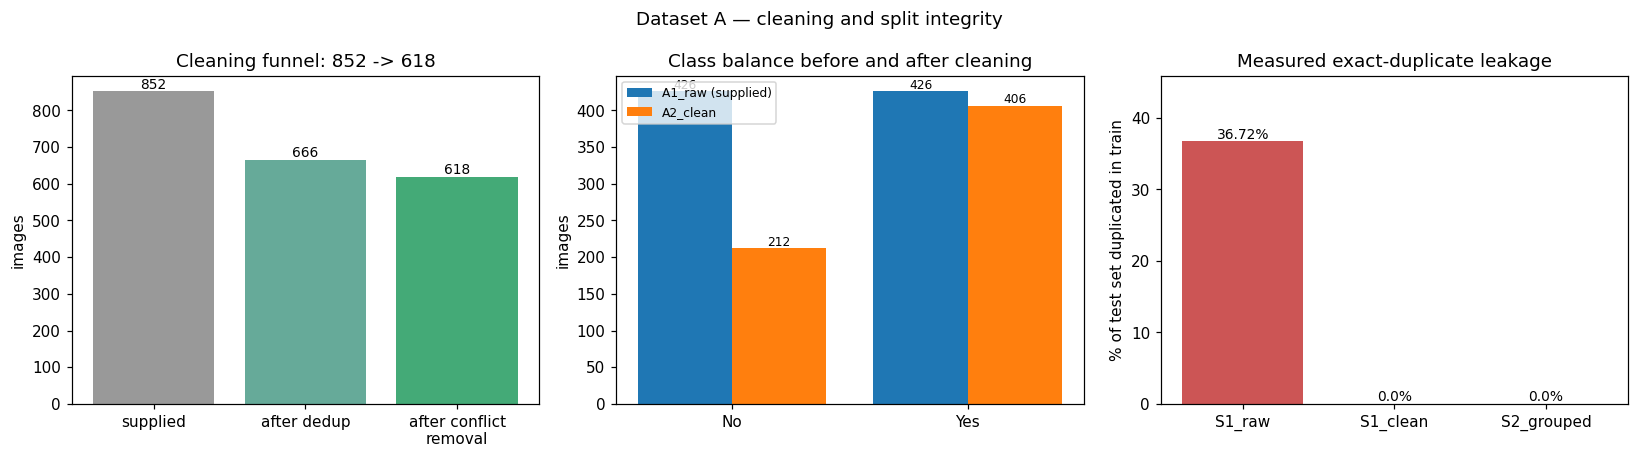

[saved] /content/drive/MyDrive/DyslexAI/results/figures/A_cleaning_and_leakage.png


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# --- Panel 1: cleaning funnel ----------------------------------------------
stages = ['supplied', 'after dedup', 'after conflict\nremoval']
counts = [len(meta),
          len(meta) - (removed['removal_reason'] == 'redundant_duplicate_copy').sum(),
          len(a2)]
bars = ax[0].bar(stages, counts, color=['#999', '#6a9', '#4a7'])
ax[0].set_ylabel('images')
ax[0].set_title('Cleaning funnel: 852 -> %d' % len(a2))
for b, c in zip(bars, counts):
    ax[0].text(b.get_x() + b.get_width()/2, c, str(c), ha='center', va='bottom', fontsize=9)

# --- Panel 2: class balance before vs after --------------------------------
labels = ['No', 'Yes']
before = [ (meta['class_label'] == l).sum() for l in labels ]
after  = [ (a2['class_label']   == l).sum() for l in labels ]
x = np.arange(len(labels))
ax[1].bar(x - 0.2, before, width=0.4, label='A1_raw (supplied)')
ax[1].bar(x + 0.2, after,  width=0.4, label='A2_clean')
ax[1].set_xticks(x); ax[1].set_xticklabels(labels)
ax[1].set_ylabel('images')
ax[1].set_title('Class balance before and after cleaning')
ax[1].legend(fontsize=8)
for i, (b, a_) in enumerate(zip(before, after)):
    ax[1].text(i - 0.2, b, str(b), ha='center', va='bottom', fontsize=8)
    ax[1].text(i + 0.2, a_, str(a_), ha='center', va='bottom', fontsize=8)

# --- Panel 3: measured test-set leakage ------------------------------------
names = ['S1_raw', 'S1_clean', 'S2_grouped']
pcts  = list(leak['test_leaked_pct'])
bars = ax[2].bar(names, pcts, color=['#c55', '#4a7', '#47a'])
ax[2].set_ylabel('% of test set duplicated in train')
ax[2].set_title('Measured exact-duplicate leakage')
ax[2].set_ylim(0, max(max(pcts) * 1.25, 1))
for b, p in zip(bars, pcts):
    ax[2].text(b.get_x() + b.get_width()/2, p, f'{p}%', ha='center', va='bottom', fontsize=9)

fig.suptitle('Dataset A — cleaning and split integrity', fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'A_cleaning_and_leakage.png', bbox_inches='tight')
plt.show()
print(f'[saved] {FIGURES_DIR / "A_cleaning_and_leakage.png"}')

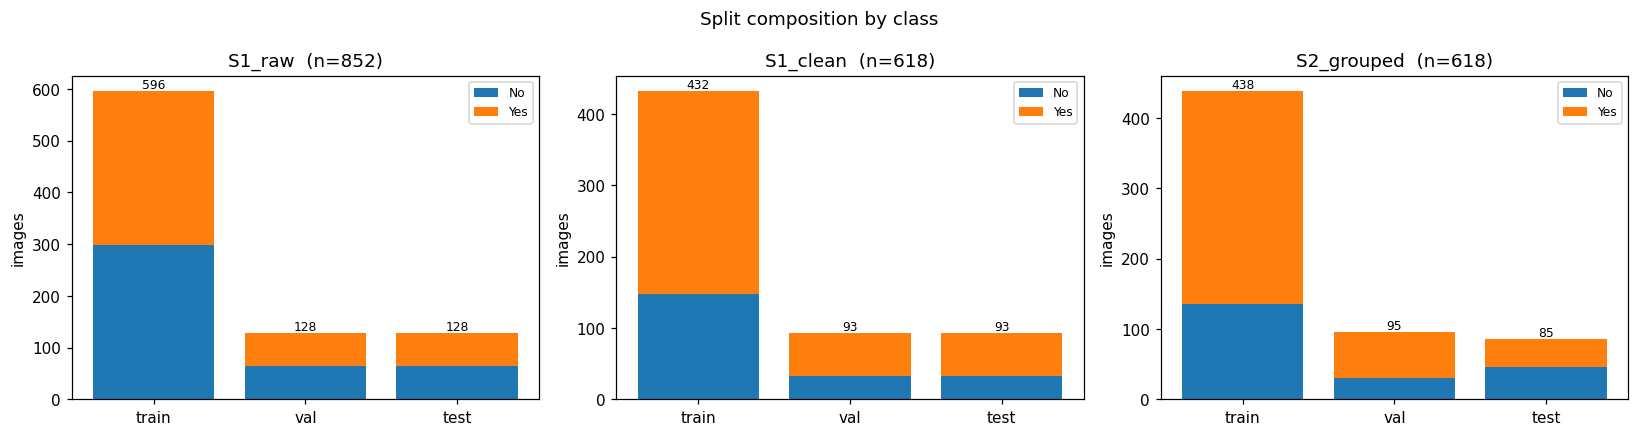

[saved] /content/drive/MyDrive/DyslexAI/results/figures/A_split_composition.png


In [ ]:
# ---- Split composition figure ---------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax_, (name, d) in zip(axes, [('S1_raw', s1_raw),
                                 ('S1_clean', s1_clean),
                                 ('S2_grouped', s2_grouped)]):
    ct = pd.crosstab(d['split'], d['class_label']).reindex(['train', 'val', 'test'])
    bottom = np.zeros(len(ct))
    for cls in ct.columns:
        ax_.bar(ct.index, ct[cls], bottom=bottom, label=cls)
        bottom += ct[cls].values
    ax_.set_title(f'{name}  (n={len(d)})')
    ax_.set_ylabel('images')
    ax_.legend(fontsize=8)
    for i, total in enumerate(bottom):
        ax_.text(i, total, str(int(total)), ha='center', va='bottom', fontsize=8)

fig.suptitle('Split composition by class', fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'A_split_composition.png', bbox_inches='tight')
plt.show()
print(f'[saved] {FIGURES_DIR / "A_split_composition.png"}')

---
# STAGE 8 — Write the Cleaning Report

In [ ]:
report = f"""
{'='*70}
DATASET A — CLEANING AND SPLIT REPORT
{'='*70}
Generated : {datetime.now().isoformat(timespec='seconds')}
Seed      : {SEED}

--- CLEANING POLICY APPLIED ------------------------------------------
  Rule 1  collapse exact duplicates to one canonical copy
          (ranked: EXIF present > original-looking filename > alphabetical)
  Rule 2  remove ALL members of cross-class contradiction groups
  Rule 3  remove corrupted files
  Rule 4  log every removal with a reason

--- BEFORE / AFTER ---------------------------------------------------
  before                     : {len(meta)}
  after                      : {len(a2)}
  removed                    : {len(removed)}
      redundant copies       : {(removed['removal_reason']=='redundant_duplicate_copy').sum()}
      cross-class conflicts  : {(removed['removal_reason']=='cross_class_label_conflict').sum()}
      corrupted              : {(removed['removal_reason']=='corrupted_file').sum()}

  duplicate groups           : {n_dup_groups}
  cross-class contradictions : {n_conflict_groups}

--- CLASS DISTRIBUTION -----------------------------------------------
  A1_raw    No={(meta['class_label']=='No').sum():>4}  Yes={(meta['class_label']=='Yes').sum():>4}
  A2_clean  No={(a2['class_label']=='No').sum():>4}  Yes={(a2['class_label']=='Yes').sum():>4}
  A2 imbalance Yes:No = {(a2['class_label']=='Yes').sum() / (a2['class_label']=='No').sum():.2f} : 1

--- SPLITS -----------------------------------------------------------
  S1_raw      A1_raw,   stratified random image-level 70/15/15
  S1_clean    A2_clean, stratified random image-level 70/15/15
  S2_grouped  A2_clean, session-held-out test
              test session : {test_group}  ({(s2_grouped['split']=='test').sum()} images)
              val          : stratified random from remaining ({(s2_grouped['split']=='val').sum()} images)
              train        : {(s2_grouped['split']=='train').sum()} images

--- LEAKAGE AUDIT ----------------------------------------------------
{leak[['split_name','n_train','n_val','n_test','test_leaked','test_leaked_pct']].to_string(index=False)}

--- LIMITATIONS ------------------------------------------------------
  * Participant IDs are unavailable. NO split in this project is
    writer-independent, and none may be described as such.
  * session_proxy is derived from EXIF capture DATE. One capture day
    contains many children, so it separates sessions, not writers.
  * 178 files carry no EXIF at all and sit in a NO_EXIF bucket that is
    an absence of information, not a real session.
  * In S2_grouped only the TEST set is session-held-out. The validation
    set is a stratified random sample and DOES share sessions with train.
  * The leakage audit detects EXACT byte duplicates only. Near-duplicates
    and same-writer images cannot be detected without participant IDs.
  * Yes/No are supplied dataset labels. They do not establish clinical
    validity and are not treated as diagnoses.
{'='*70}
""".strip()

print(report)

CLEAN_REPORT = REPORTS_DIR / 'dataset_a_cleaning_report.txt'
CLEAN_REPORT.write_text(report)
print(f'\n[saved] {CLEAN_REPORT}')

DATASET A — CLEANING AND SPLIT REPORT
Generated : 2026-09-23T02:03:03
Seed      : 42

--- CLEANING POLICY APPLIED ------------------------------------------
  Rule 1  collapse exact duplicates to one canonical copy
          (ranked: EXIF present > original-looking filename > alphabetical)
  Rule 2  remove ALL members of cross-class contradiction groups
  Rule 3  remove corrupted files
  Rule 4  log every removal with a reason

--- BEFORE / AFTER ---------------------------------------------------
  before                     : 852
  after                      : 618
  removed                    : 234
      redundant copies       : 186
      cross-class conflicts  : 48
      corrupted              : 0

  duplicate groups           : 147
  cross-class contradictions : 20

--- CLASS DISTRIBUTION -----------------------------------------------
  A1_raw    No= 426  Yes= 426
  A2_clean  No= 212  Yes= 406
  A2 imbalance Yes:No = 1.92 : 1

--- SPLITS -------------------------------------------

---
# STAGE 9 — Experiment Log

## What we actually did

1. Rebuilt the extracted images and reloaded the master metadata from Notebook 01.
2. Wrote an explicit four-rule cleaning policy **before** touching the data.
3. Selected one canonical copy per duplicate group using a deterministic ranking
   (EXIF present, then original-looking filename, then alphabetical).
4. Removed all members of the 20 cross-class contradiction groups, on the grounds that at
   least one label in each is provably wrong and the dataset does not say which.
5. Produced two dataset versions — **A1_raw** (untouched) and **A2_clean** — and a removal
   log recording every excluded file with its reason.
6. Verified the cleaning with six assertions covering uniqueness, conflicts, corruption,
   row reconciliation, reason completeness and file existence.
7. Built three splits and **measured** exact-duplicate leakage in each.

## What we learned

- Cleaning reduces the dataset from 852 files to roughly 618 genuinely distinct images.
- The supplied 50/50 class balance does not survive deduplication; the real ratio is close
  to 2 Yes : 1 No.
- A naive random split on the supplied files puts exact copies of training images into the
  test set. We measured that percentage rather than assuming it.
- Session grouping is available but weak: four capture days plus an unknown bucket.

## What we can tell

> We treated the public dataset as something to audit rather than something to trust.
> After fingerprinting every file we found that the advertised balanced 852-image dataset
> contains roughly 618 distinct images, that the balance was achieved by duplicating files
> in one class, and that a number of images carry contradictory labels. We built a cleaned
> version with a documented removal log, and we will report results on both the raw and
> cleaned versions so that the effect of these problems is visible in our numbers rather
> than hidden inside them.

## Limitations we are carrying forward

| Limitation | Effect on our claims |
|---|---|
| No participant IDs | We cannot claim a writer-independent result. Ever. |
| Session proxy is a day, not a person | Reduces session artefacts only, not writer overlap |
| 178 files with no EXIF | A bucket of unknowns, not a real group |
| Leakage audit sees exact copies only | Near-duplicates remain unmeasurable |
| Class imbalance after cleaning | Accuracy alone will be misleading; we need per-class metrics |

## Requirements this generates for our own Urdu dataset

| Problem here | Requirement for our collection |
|---|---|
| Balance achieved by copying files | Class balance must come from recruitment, never duplication |
| Same image under two labels | One label per participant, assigned once, stored centrally |
| No way to group by writer | `participant_id` recorded at capture, mandatory field |
| No way to detect near-duplicates | Hash on ingest **and** log which task each image belongs to |
| Sessions unrecoverable | Record session ID, date, location and operator per capture |
